In [12]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import joblib


def find_project_root():
    """
    Find project_01_human_activity_recognition root automatically,
    whether VS Code starts from the repo root or from the notebook folder.
    """
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        # Case 1: we are already inside project_01_human_activity_recognition
        if (path / "data" / "processed").exists() and (path / "ml").exists():
            return path

        # Case 2: we are at the main repo root
        candidate = path / "project_01_human_activity_recognition"
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError("Could not find project_01_human_activity_recognition root.")


PROJECT_ROOT = find_project_root()

paths = {
    "features_csv": PROJECT_ROOT / "data" / "processed" / "imu_statistical_features.csv",
    "raw_windows_npz": PROJECT_ROOT / "data" / "processed" / "imu_raw_windows.npz",
    "metrics_json": PROJECT_ROOT / "results" / "random_forest_metrics.json",
    "confusion_matrix_csv": PROJECT_ROOT / "results" / "random_forest_confusion_matrix.csv",
    "model_joblib": PROJECT_ROOT / "models" / "saved_models" / "random_forest_model.joblib",
}

print("Project root:")
print(PROJECT_ROOT)

print("\nChecking required files:")
for name, path in paths.items():
    print(f"{name:25s} -> {'FOUND' if path.exists() else 'MISSING'}")
    print(f"  {path}")

# Load files
features_df = pd.read_csv(paths["features_csv"])
raw_npz = np.load(paths["raw_windows_npz"])

with open(paths["metrics_json"], "r") as f:
    metrics = json.load(f)

confusion_df = pd.read_csv(paths["confusion_matrix_csv"], index_col=0)
model = joblib.load(paths["model_joblib"])

print("\nLoaded successfully.")

print("\nFeature dataset shape:")
print(features_df.shape)

print("\nFeature columns:")
print(features_df.columns.tolist())

print("\nRaw NPZ keys:")
print(raw_npz.files)

print("\nRaw NPZ array shapes:")
for key in raw_npz.files:
    print(f"{key}: {raw_npz[key].shape}")

print("\nMetrics keys:")
print(metrics.keys())

print("\nConfusion matrix shape:")
print(confusion_df.shape)

print("\nModel type:")
print(type(model))

Project root:
/home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition

Checking required files:
features_csv              -> FOUND
  /home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/data/processed/imu_statistical_features.csv
raw_windows_npz           -> FOUND
  /home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/data/processed/imu_raw_windows.npz
metrics_json              -> FOUND
  /home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/results/random_forest_metrics.json
confusion_matrix_csv      -> FOUND
  /home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/results/random_forest_confusion_matrix.csv
model_joblib              -> FOUND
  /home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/models/saved_models/rand

Label distribution:
label
backward_motion        116
circular_motion        115
fall_detection         116
forward_motion         116
gesture_recognition    116
idle                   116
left_tilt              116
right_tilt             116
shake                  116
Name: count, dtype: int64

Total windows: 1043
Number of classes: 9


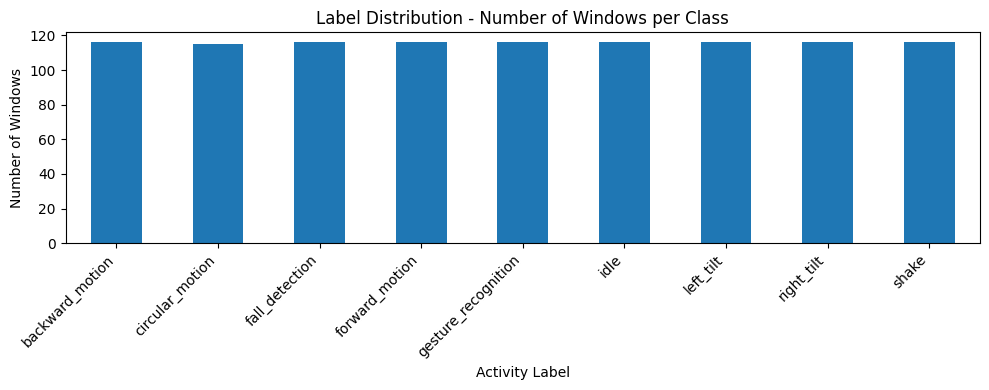

In [13]:
import matplotlib.pyplot as plt

label_counts = features_df["label"].value_counts().sort_index()

print("Label distribution:")
print(label_counts)

print("\nTotal windows:", label_counts.sum())
print("Number of classes:", label_counts.shape[0])

plt.figure(figsize=(10, 4))
label_counts.plot(kind="bar")
plt.title("Label Distribution - Number of Windows per Class")
plt.xlabel("Activity Label")
plt.ylabel("Number of Windows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

X shape: (1043, 50, 6)
y shape: (1043,)
labels: ['backward_motion' 'circular_motion' 'fall_detection' 'forward_motion'
 'gesture_recognition' 'idle' 'left_tilt' 'right_tilt' 'shake']


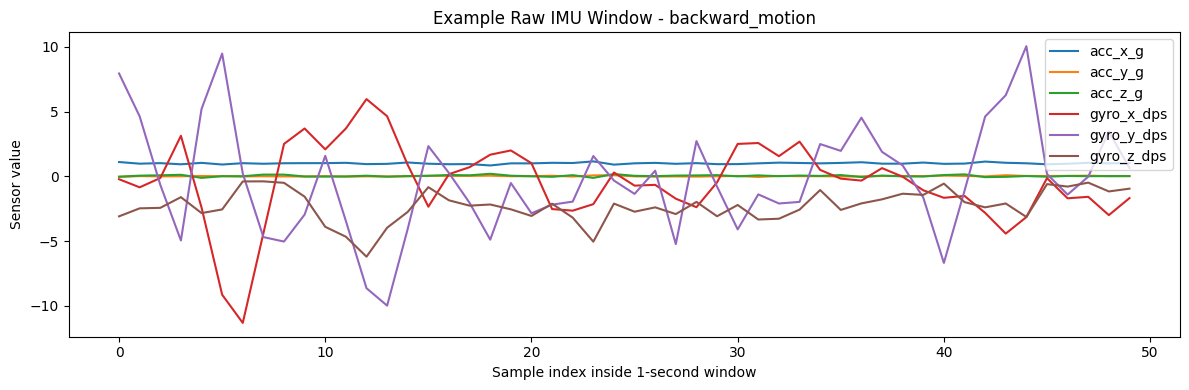

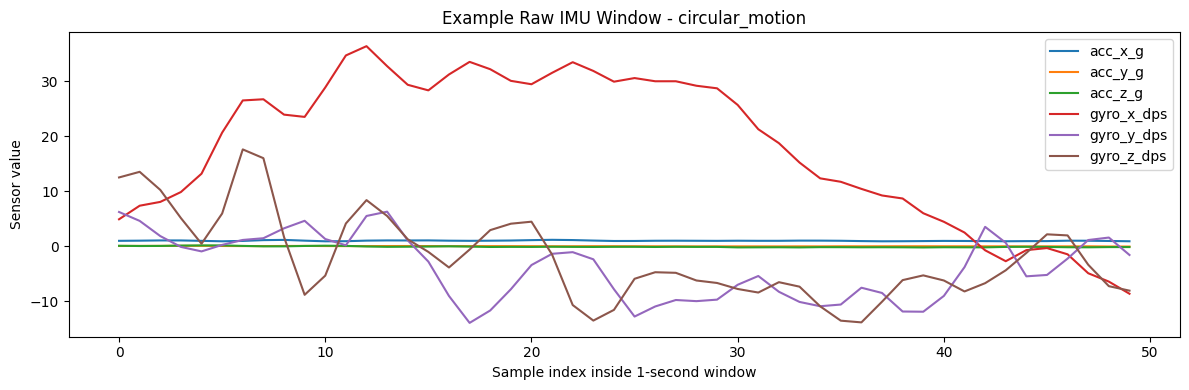

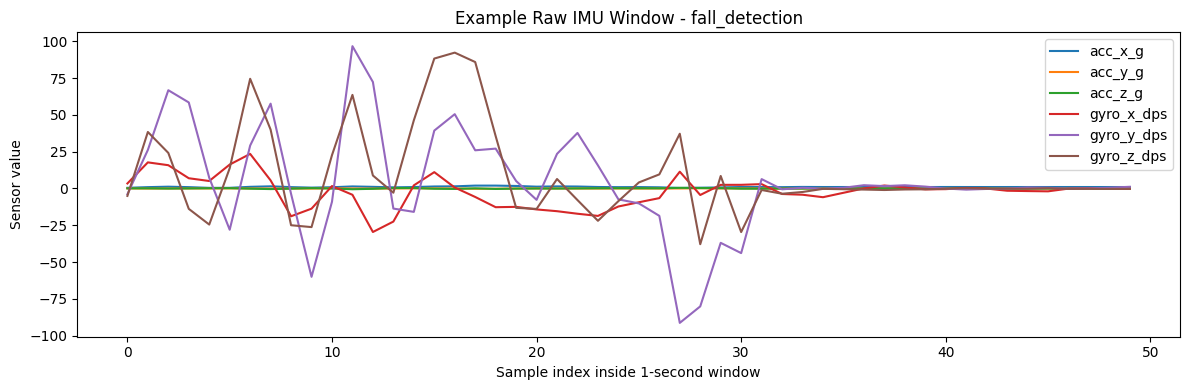

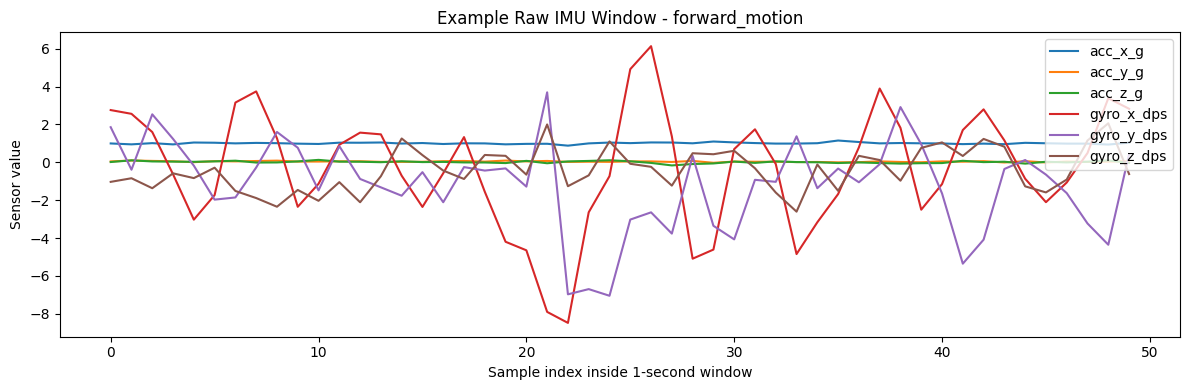

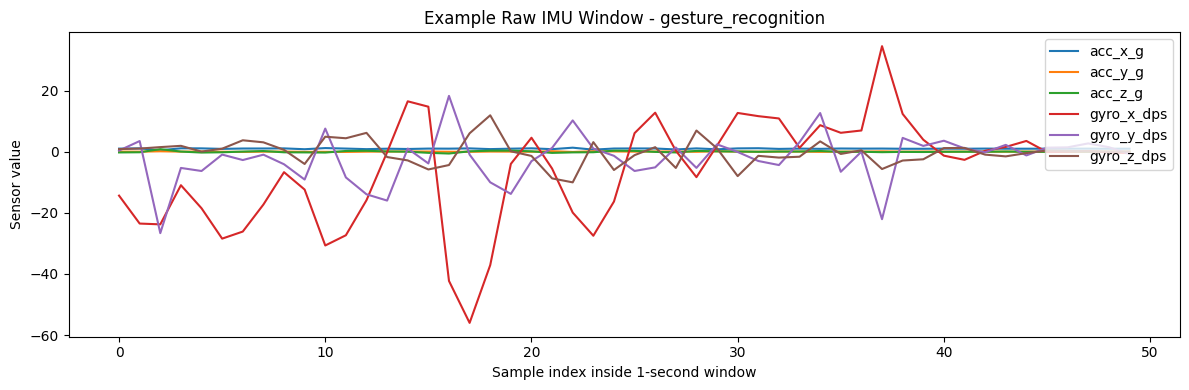

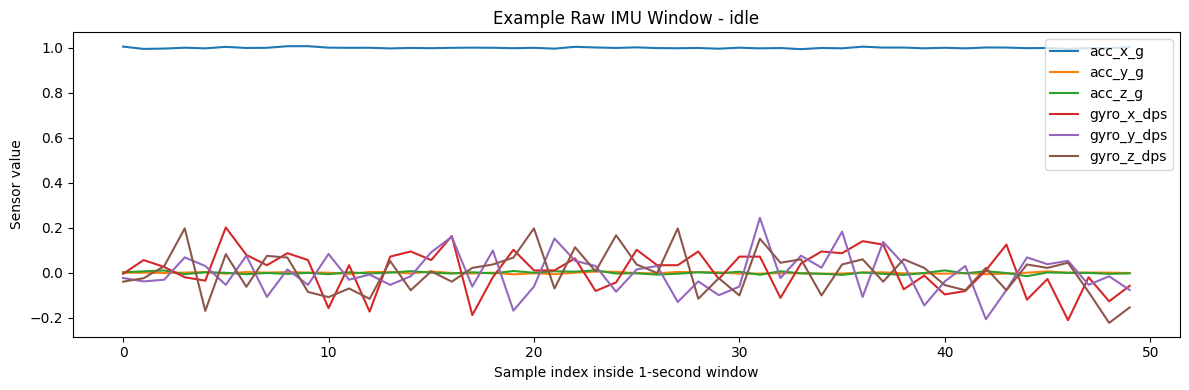

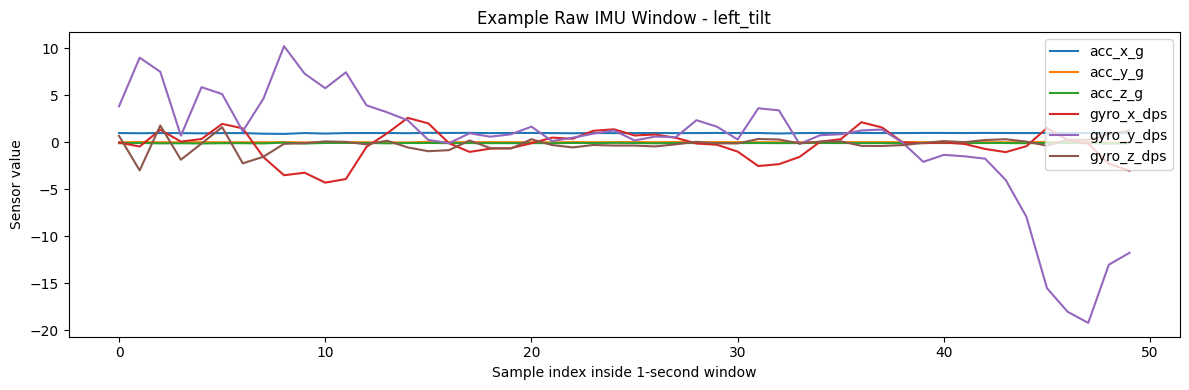

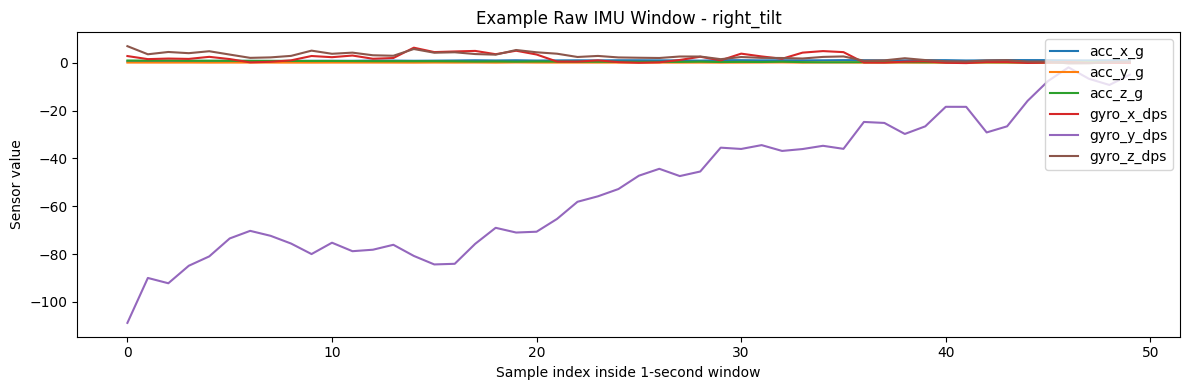

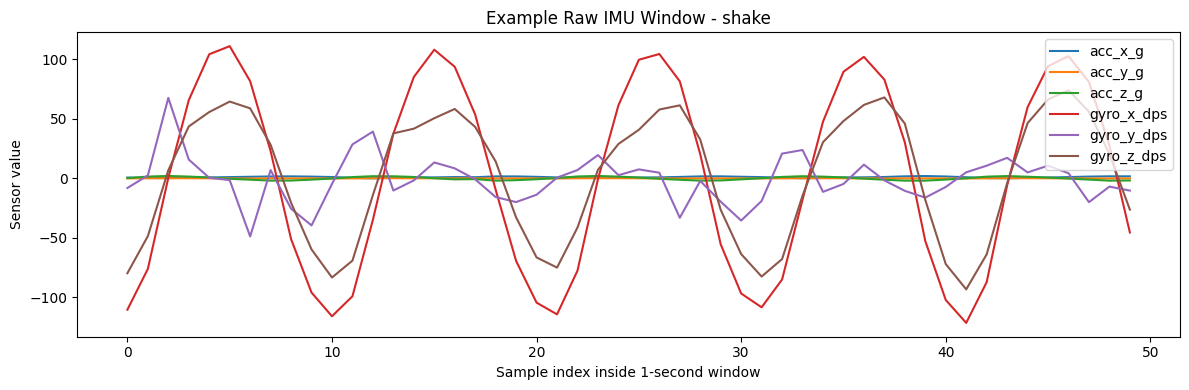

In [14]:
# Raw IMU window visualization

X = raw_npz["X"]
y = raw_npz["y"]
labels = raw_npz["labels"]

signal_names = [
    "acc_x_g",
    "acc_y_g",
    "acc_z_g",
    "gyro_x_dps",
    "gyro_y_dps",
    "gyro_z_dps",
]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("labels:", labels)

# Plot one example window from each class
for class_id, label in enumerate(labels):
    indices = np.where(y == class_id)[0]
    example_index = indices[0]
    window = X[example_index]

    plt.figure(figsize=(12, 4))

    for signal_index, signal_name in enumerate(signal_names):
        plt.plot(window[:, signal_index], label=signal_name)

    plt.title(f"Example Raw IMU Window - {label}")
    plt.xlabel("Sample index inside 1-second window")
    plt.ylabel("Sensor value")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [15]:
# Check global min/max values for each raw IMU signal

X_flat = X.reshape(-1, X.shape[-1])

range_df = pd.DataFrame({
    "signal": signal_names,
    "min": X_flat.min(axis=0),
    "max": X_flat.max(axis=0),
    "mean": X_flat.mean(axis=0),
    "std": X_flat.std(axis=0),
})

range_df

,signal,min,max,mean,std
0,acc_x_g,-1.330100,1.957700,0.901496,0.357508
1,acc_y_g,-1.981900,1.421900,0.015984,0.079895
2,acc_z_g,-1.912300,2.087600,0.006909,0.557889
3,gyro_x_dps,-182.240997,197.652100,-0.027664,31.069275
4,gyro_y_dps,-249.557297,250.709900,-0.029785,38.345951
5,gyro_z_dps,-250.764404,214.105804,0.229452,25.326363


In [16]:
# Locate suspicious acc_x_g outliers

outlier_threshold = 10.0  # acceleration above 10g is suspicious for this project

outlier_positions = np.argwhere(np.abs(X[:, :, 0]) > outlier_threshold)

print("Number of suspicious acc_x_g samples:", len(outlier_positions))

for pos in outlier_positions[:20]:
    window_index, sample_index = pos
    value = X[window_index, sample_index, 0]

    row = features_df.iloc[window_index]

    print("\nOutlier found:")
    print("window_index:", window_index)
    print("sample_index_inside_window:", sample_index)
    print("acc_x_g value:", value)
    print("label:", row["label"])
    print("source_file:", row["source_file"])
    print("window_start:", row["window_start"])
    print("window_end:", row["window_end"])

Number of suspicious acc_x_g samples: 0


In [17]:
# Inspect the original CSV file that contains the suspicious sample

bad_source_file = "circular_motion_20260609_091351.csv"
bad_csv_path = PROJECT_ROOT / "data" / "raw" / "final" / bad_source_file

bad_df = pd.read_csv(bad_csv_path)

print("CSV path:")
print(bad_csv_path)

print("\nCSV shape:")
print(bad_df.shape)

print("\nFirst 10 rows:")
display(bad_df.head(10))

print("\nRange check in this CSV:")
display(bad_df.describe())

CSV path:
/home/abdo/Workspace/ITI/Projects/TinyML-Embedded-AI-Systems/project_01_human_activity_recognition/data/raw/final/circular_motion_20260609_091351.csv

CSV shape:
(1199, 8)

First 10 rows:


,timestamp_ms,acc_x_g,acc_y_g,acc_z_g,gyro_x_dps,gyro_y_dps,gyro_z_dps,label
0,2392900,1.0002,0.0630,0.0987,4.9193,6.2442,12.5257,circular_motion
1,2392920,1.0292,0.0745,0.0572,7.3849,4.6259,13.5486,circular_motion
2,2392940,1.0717,0.0786,0.0718,8.0796,1.8625,10.2585,circular_motion
3,2392960,1.0690,0.0938,0.1311,9.8735,-0.1069,5.1364,circular_motion
4,2392980,0.9946,0.0935,0.1656,13.2094,-0.9237,0.4723,circular_motion
5,2393000,0.9157,0.0620,0.1656,20.6826,0.2595,5.9684,circular_motion
6,2393020,0.9831,0.0437,0.0784,26.5300,1.1602,17.6249,circular_motion
7,2393040,1.1262,0.0425,0.0015,26.7437,1.4732,16.0295,circular_motion
8,2393060,1.1689,0.0642,-0.0024,23.9498,3.2747,1.6936,circular_motion
9,2393080,1.0314,0.0740,0.0684,23.5376,4.6412,-8.8178,circular_motion



Range check in this CSV:


,timestamp_ms,acc_x_g,acc_y_g,acc_z_g,gyro_x_dps,gyro_y_dps,gyro_z_dps
count,1.199000e+03,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000
mean,2.404880e+06,0.995180,-0.020485,-0.043441,1.007321,-1.452647,0.825238
std,6.925316e+03,0.114166,0.082430,0.168988,31.588903,13.421637,13.455877
min,2.392900e+06,0.606600,-0.237300,-0.608600,-79.050200,-50.091700,-43.474300
25%,2.398890e+06,0.922300,-0.087050,-0.166500,-26.176150,-10.080200,-8.756700
50%,2.404880e+06,0.994600,-0.019500,-0.036300,1.491800,-0.045900,0.472300
75%,2.410870e+06,1.066500,0.041800,0.082350,27.778050,6.969400,10.628750
max,2.416860e+06,1.320800,0.256800,0.426600,73.354400,46.068600,38.411200


In [19]:
# Preview statistical feature table

print("Feature table shape:", features_df.shape)

display(features_df.head())

metadata_columns = ["label", "label_id", "source_file", "window_start", "window_end"]
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

print("Number of input features:", len(feature_columns))
print("Number of metadata/target columns:", len(metadata_columns))

print("\nFirst 10 input feature columns:")
print(feature_columns[:10])

Feature table shape: (1043, 53)


,acc_x_g_mean,acc_x_g_std,acc_x_g_var,acc_x_g_min,acc_x_g_max,acc_x_g_rms,acc_x_g_energy,acc_y_g_mean,acc_y_g_std,acc_y_g_var,...,acc_mag_std,acc_mag_max,gyro_mag_mean,gyro_mag_std,gyro_mag_max,label,label_id,source_file,window_start,window_end
0,0.999074,0.057996,0.003364,0.8356,1.1506,1.000756,50.075620,0.011104,0.028324,0.000802,...,0.056309,1.159141,5.002101,2.875160,13.411149,backward_motion,0,backward_motion_20260609_091258.csv,0,50
1,1.003352,0.057115,0.003262,0.8356,1.1506,1.004976,50.498875,0.016784,0.028599,0.000818,...,0.055541,1.159141,4.213712,2.439231,12.193931,backward_motion,0,backward_motion_20260609_091258.csv,10,60
2,1.009572,0.048586,0.002361,0.8999,1.1506,1.010740,51.079807,0.018350,0.029460,0.000868,...,0.048143,1.159141,3.535898,1.874251,10.985644,backward_motion,0,backward_motion_20260609_091258.csv,20,70
3,1.008484,0.039488,0.001559,0.9260,1.1357,1.009257,50.929966,0.019920,0.025409,0.000646,...,0.039482,1.137558,3.018252,1.974599,10.985644,backward_motion,0,backward_motion_20260609_091258.csv,30,80
4,1.006718,0.035582,0.001266,0.9260,1.1357,1.007347,50.737362,0.019732,0.031876,0.001016,...,0.035488,1.137558,2.908217,2.031440,10.985644,backward_motion,0,backward_motion_20260609_091258.csv,40,90


Number of input features: 48
Number of metadata/target columns: 5

First 10 input feature columns:
['acc_x_g_mean', 'acc_x_g_std', 'acc_x_g_var', 'acc_x_g_min', 'acc_x_g_max', 'acc_x_g_rms', 'acc_x_g_energy', 'acc_y_g_mean', 'acc_y_g_std', 'acc_y_g_var']


In [20]:
# Compare statistical features between idle and shake

metadata_columns = ["label", "label_id", "source_file", "window_start", "window_end"]
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

idle_example = features_df[features_df["label"] == "idle"].iloc[0]
shake_example = features_df[features_df["label"] == "shake"].iloc[0]

selected_features = [
    "acc_x_g_std",
    "acc_y_g_std",
    "acc_z_g_std",
    "gyro_x_dps_std",
    "gyro_y_dps_std",
    "gyro_z_dps_std",
    "acc_mag_mean",
    "acc_mag_std",
    "gyro_mag_mean",
    "gyro_mag_std",
]

comparison_df = pd.DataFrame({
    "feature": selected_features,
    "idle": [idle_example[f] for f in selected_features],
    "shake": [shake_example[f] for f in selected_features],
})

display(comparison_df)

,feature,idle,shake
0,acc_x_g_std,0.002859,0.524806
1,acc_y_g_std,0.003218,0.064241
2,acc_z_g_std,0.005538,1.323796
3,gyro_x_dps_std,0.093053,79.431465
4,gyro_y_dps_std,0.090674,19.762745
5,gyro_z_dps_std,0.094148,52.388350
6,acc_mag_mean,0.999547,1.633209
7,acc_mag_std,0.002855,0.552355
8,gyro_mag_mean,0.149823,90.304685
9,gyro_mag_std,0.058325,36.086953


In [21]:
# Display confusion matrix table

print("Confusion Matrix:")
display(confusion_df)

# Find misclassified pairs
misclassifications = []

for true_label in confusion_df.index:
    for predicted_label in confusion_df.columns:
        value = confusion_df.loc[true_label, predicted_label]

        if true_label != predicted_label and value > 0:
            misclassifications.append({
                "true_label": true_label,
                "predicted_label": predicted_label,
                "count": value,
            })

misclassification_df = pd.DataFrame(misclassifications)

print("Misclassifications:")
if len(misclassification_df) == 0:
    print("No misclassifications found.")
else:
    display(misclassification_df)

Confusion Matrix:


,backward_motion,circular_motion,fall_detection,forward_motion,gesture_recognition,idle,left_tilt,right_tilt,shake
backward_motion,23,0,0,0,0,0,0,0,0
circular_motion,0,23,0,0,0,0,0,0,0
fall_detection,0,0,23,0,0,0,0,0,0
forward_motion,1,0,0,22,0,0,0,0,0
gesture_recognition,0,0,0,0,24,0,0,0,0
idle,0,0,0,0,0,23,0,0,0
left_tilt,0,0,0,0,0,0,23,0,0
right_tilt,0,0,0,0,0,0,0,24,0
shake,0,0,0,0,0,0,0,0,23


Misclassifications:


,true_label,predicted_label,count
0,forward_motion,backward_motion,1


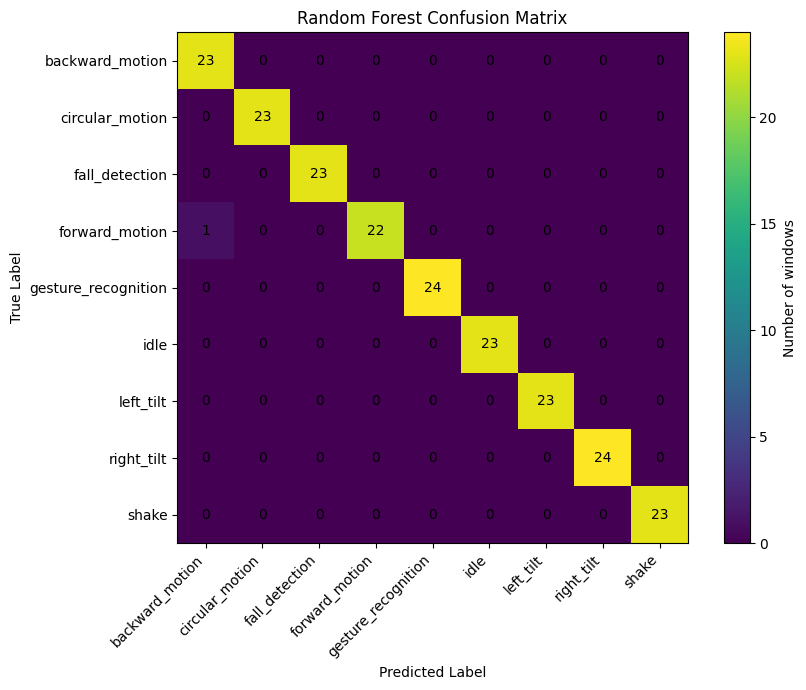

In [22]:
# Plot confusion matrix

plt.figure(figsize=(9, 7))
plt.imshow(confusion_df.values)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(confusion_df.columns)),
    labels=confusion_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(confusion_df.index)),
    labels=confusion_df.index
)

# Write numbers inside cells
for i in range(confusion_df.shape[0]):
    for j in range(confusion_df.shape[1]):
        plt.text(
            j,
            i,
            confusion_df.iloc[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of windows")
plt.tight_layout()
plt.show()

In [23]:
# Display classification report from metrics JSON

print("Metrics keys:")
print(metrics.keys())

report = metrics.get("classification_report", None)

if report is None:
    print("classification_report not found in metrics JSON.")
    print("Available metrics:")
    display(metrics)
else:
    report_df = pd.DataFrame(report).T
    display(report_df)

Metrics keys:
dict_keys(['model', 'features_file', 'num_total_windows', 'num_train_windows', 'num_test_windows', 'accuracy', 'labels', 'classification_report', 'model_path'])


,precision,recall,f1-score,support
backward_motion,0.958333,1.000000,0.978723,23.000000
circular_motion,1.000000,1.000000,1.000000,23.000000
fall_detection,1.000000,1.000000,1.000000,23.000000
forward_motion,1.000000,0.956522,0.977778,23.000000
gesture_recognition,1.000000,1.000000,1.000000,24.000000
idle,1.000000,1.000000,1.000000,23.000000
left_tilt,1.000000,1.000000,1.000000,23.000000
right_tilt,1.000000,1.000000,1.000000,24.000000
shake,1.000000,1.000000,1.000000,23.000000
accuracy,0.995215,0.995215,0.995215,0.995215


Top 15 most important features:


,feature,importance
26,gyro_x_dps_rms,0.049347
27,gyro_x_dps_energy,0.049162
17,acc_z_g_min,0.048223
40,gyro_z_dps_rms,0.042474
18,acc_z_g_max,0.041837
41,gyro_z_dps_energy,0.039309
23,gyro_x_dps_var,0.035530
22,gyro_x_dps_std,0.033849
14,acc_z_g_mean,0.033728
16,acc_z_g_var,0.031718


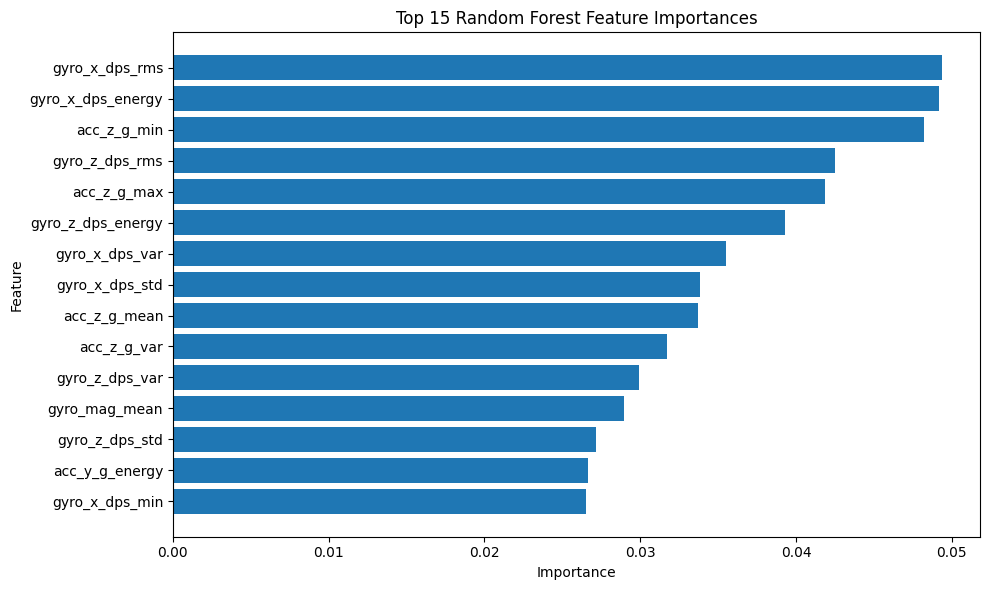

In [25]:
# Feature importance analysis

metadata_columns = ["label", "label_id", "source_file", "window_start", "window_end"]
feature_columns = [col for col in features_df.columns if col not in metadata_columns]

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": importances,
}).sort_values("importance", ascending=False)

print("Top 15 most important features:")
display(importance_df.head(15))

plt.figure(figsize=(10, 6))
top_n = 15
plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1],
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

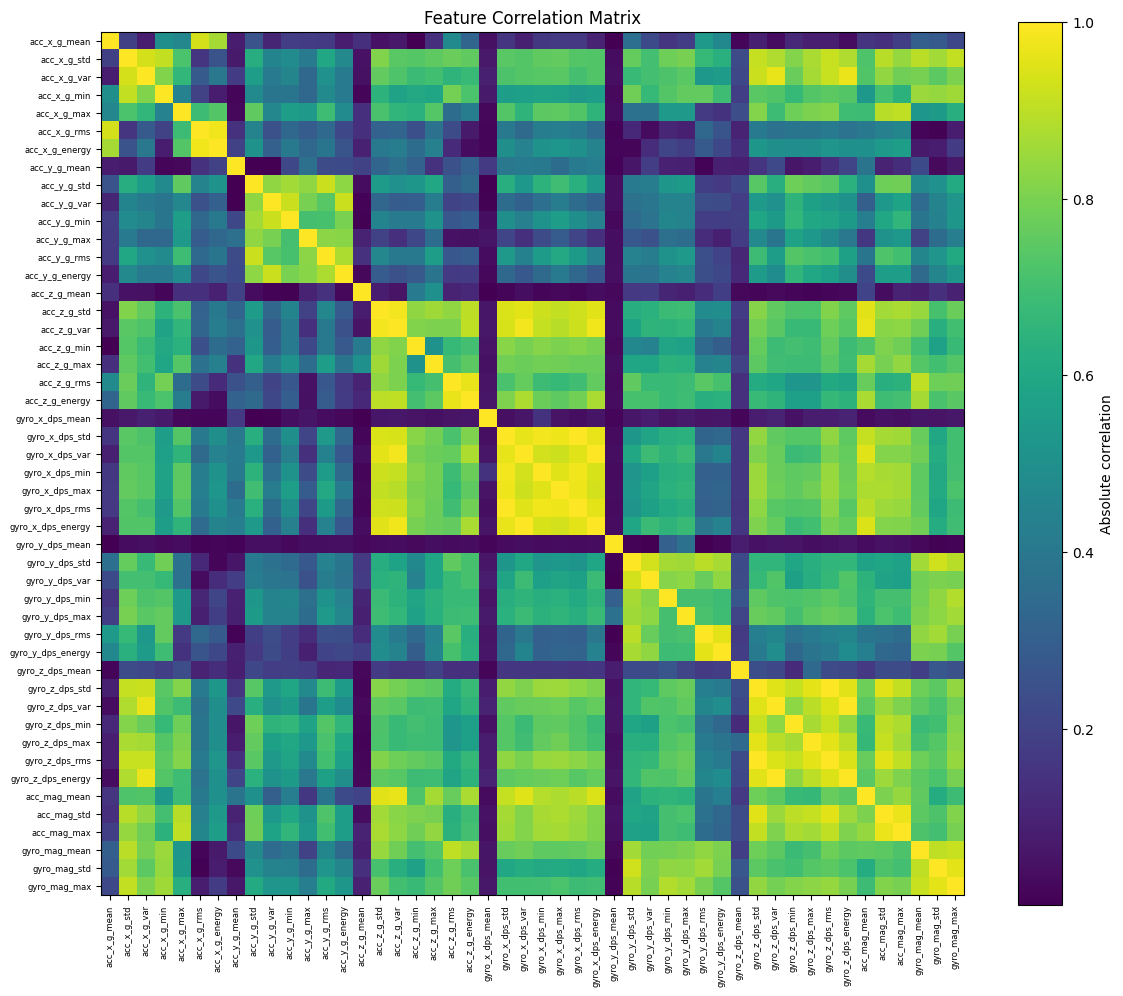

Number of highly correlated feature pairs: 33


,feature_1,feature_2,correlation
28,gyro_z_dps_var,gyro_z_dps_energy,0.999575
25,gyro_z_dps_std,gyro_z_dps_rms,0.998798
16,gyro_x_dps_var,gyro_x_dps_energy,0.998781
14,gyro_x_dps_std,gyro_x_dps_rms,0.996472
7,acc_z_g_var,gyro_x_dps_var,0.983547
12,gyro_x_dps_std,gyro_x_dps_min,0.981008
3,acc_z_g_std,acc_z_g_var,0.980921
8,acc_z_g_var,gyro_x_dps_energy,0.979856
19,gyro_x_dps_min,gyro_x_dps_rms,0.979280
2,acc_x_g_rms,acc_x_g_energy,0.977828


In [26]:
# Correlation matrix for input features

corr_df = features_df[feature_columns].corr().abs()

plt.figure(figsize=(12, 10))
plt.imshow(corr_df.values)
plt.title("Feature Correlation Matrix")
plt.colorbar(label="Absolute correlation")

plt.xticks(
    ticks=np.arange(len(feature_columns)),
    labels=feature_columns,
    rotation=90,
    fontsize=6
)

plt.yticks(
    ticks=np.arange(len(feature_columns)),
    labels=feature_columns,
    fontsize=6
)

plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
high_corr_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):
        corr_value = corr_df.iloc[i, j]

        if corr_value > 0.95:
            high_corr_pairs.append({
                "feature_1": feature_columns[i],
                "feature_2": feature_columns[j],
                "correlation": corr_value,
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("correlation", ascending=False)

print("Number of highly correlated feature pairs:", len(high_corr_df))
display(high_corr_df.head(20))

In [27]:
# Analyze overlapping windows and source files

print("Number of unique source files:")
print(features_df["source_file"].nunique())

print("\nWindows per source file:")
display(features_df["source_file"].value_counts())

print("\nExample window ranges:")
display(features_df[["label", "source_file", "window_start", "window_end"]].head(15))

Number of unique source files:
9

Windows per source file:


source_file
backward_motion_20260609_091258.csv        116
fall_detection_20260609_091454.csv         116
forward_motion_20260609_091218.csv         116
gesture_recognition_20260609_091647.csv    116
idle_20260609_090656.csv                   116
right_tilt_20260609_091131.csv             116
left_tilt_20260609_091046.csv              116
shake_20260609_091000.csv                  116
circular_motion_20260609_091351.csv        115
Name: count, dtype: int64


Example window ranges:


,label,source_file,window_start,window_end
0,backward_motion,backward_motion_20260609_091258.csv,0,50
1,backward_motion,backward_motion_20260609_091258.csv,10,60
2,backward_motion,backward_motion_20260609_091258.csv,20,70
3,backward_motion,backward_motion_20260609_091258.csv,30,80
4,backward_motion,backward_motion_20260609_091258.csv,40,90
5,backward_motion,backward_motion_20260609_091258.csv,50,100
6,backward_motion,backward_motion_20260609_091258.csv,60,110
7,backward_motion,backward_motion_20260609_091258.csv,70,120
8,backward_motion,backward_motion_20260609_091258.csv,80,130
9,backward_motion,backward_motion_20260609_091258.csv,90,140


# Random Forest Baseline Analysis

## Summary

The Random Forest model was trained on statistical features extracted from 1-second IMU windows.

Each raw window contains:

- 50 samples
- 6 IMU signals:
  - acc_x_g
  - acc_y_g
  - acc_z_g
  - gyro_x_dps
  - gyro_y_dps
  - gyro_z_dps

Instead of feeding the full raw time-series window directly to Random Forest, statistical features were extracted from each window, such as mean, standard deviation, variance, min, max, RMS, energy, acceleration magnitude, and gyroscope magnitude.

## Dataset Quality

The dataset contains 9 activity classes.

After cleaning one corrupted startup sample from the circular_motion recording, the processed dataset contains 1043 windows.

The dataset is almost balanced:

- 8 classes have 116 windows
- circular_motion has 115 windows

A range check confirmed that the IMU values are now reasonable after removing the corrupted sample.

## Model Performance

The Random Forest achieved 99.52% accuracy on the current random train/test split.

The confusion matrix showed only one misclassification:

- one forward_motion window was predicted as backward_motion

This makes sense because forward and backward motion can have similar IMU patterns.

## Feature Importance

The most important features were mainly gyroscope-based features, especially RMS, energy, variance, and standard deviation from gyro_x and gyro_z.

Accelerometer Z-axis features were also important, which makes sense for tilt, idle, and fall-related motion.

## Important Limitation

The current accuracy should be treated as a baseline, not final proof of real-world performance.

The dataset uses overlapping windows:

- window size = 50 samples
- stride = 10 samples
- overlap = 80%

Because the train/test split is random, very similar neighboring windows may appear in both training and testing sets.

This can make the test result optimistic.

A stronger validation method would be session-based splitting, where the model is trained on some recording sessions and tested on different recording sessions.

## Conclusion

The Random Forest baseline is strong and useful for understanding the dataset and feature behavior.

However, before deployment, stronger validation and additional models should be tested, including SVM and a small neural network suitable for TinyML deployment.